#23CO315 - Piyusha Supe
**NLP - Practical 3**


Perform text cleaning, perform lemmatization (any method), remove stop words (any
method), label encoding. Create representations using TF-IDF. Save outputs.
Dataset: https://github.com/PICT-NLP/BE-NLP-Elective/blob/main/3
Preprocessing/News_dataset.pickle


In [2]:
# If needed (uncomment)
!pip install pandas numpy nltk scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Download resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

plt.style.use('default')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
from google.colab import files

uploaded = files.upload()


Saving Practical_3_News_dataset.pickle to Practical_3_News_dataset.pickle


In [4]:
# Load pickle dataset
df = pd.read_pickle("/content/Practical_3_News_dataset.pickle")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2225, 6)


,File_Name,Content,Category,Complete_Filename,id,News_length
0,001.txt,Ad sales boost Time Warner profit\r\n\r\nQuart...,business,001.txt-business,1,2569
1,002.txt,Dollar gains on Greenspan speech\r\n\r\nThe do...,business,002.txt-business,1,2257
2,003.txt,Yukos unit buyer faces loan claim\r\n\r\nThe o...,business,003.txt-business,1,1557
3,004.txt,High fuel prices hit BA's profits\r\n\r\nBriti...,business,004.txt-business,1,2421
4,005.txt,Pernod takeover talk lifts Domecq\r\n\r\nShare...,business,005.txt-business,1,1575


In [7]:
# Main text column
df['Content'] = df['Content'].fillna('')

# Label column
df['Category'] = df['Category'].fillna('')

print(df[['Content', 'Category']].head())

                                             Content  Category
0  Ad sales boost Time Warner profit\r\n\r\nQuart...  business
1  Dollar gains on Greenspan speech\r\n\r\nThe do...  business
2  Yukos unit buyer faces loan claim\r\n\r\nThe o...  business
3  High fuel prices hit BA's profits\r\n\r\nBriti...  business
4  Pernod takeover talk lifts Domecq\r\n\r\nShare...  business


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.strip()
    return text

df['clean_text'] = df['Content'].apply(clean_text)

In [10]:
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

df['tokens'] = df['clean_text'].apply(preprocess)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [11]:
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))

df[['processed_text']].head()

,processed_text
0,ad sale boost time warner profit quarterly pro...
1,dollar gain greenspan speech dollar hit highes...
2,yukos unit buyer face loan claim owner embattl...
3,high fuel price hit ba profit british airway b...
4,pernod takeover talk lift domecq share uk drin...


In [12]:
label_encoder = LabelEncoder()

df['encoded_label'] = label_encoder.fit_transform(df['Category'])

df[['Category', 'encoded_label']].head()

,Category,encoded_label
0,business,0
1,business,0
2,business,0
3,business,0
4,business,0


In [13]:
tfidf = TfidfVectorizer(max_features=5000)

tfidf_matrix = tfidf.fit_transform(df['processed_text'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("TF-IDF Shape:", tfidf_df.shape)
tfidf_df.head()

TF-IDF Shape: (2225, 5000)


,aaa,abandoned,abbas,abc,ability,able,abn,abortion,abroad,absence,...,yuganskneftegas,yukos,yushchenko,zealand,zero,zombie,zone,zurich,âbn,âm
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.034602
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.387334,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.036525
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.029146,0.156679
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.056913,0.000000


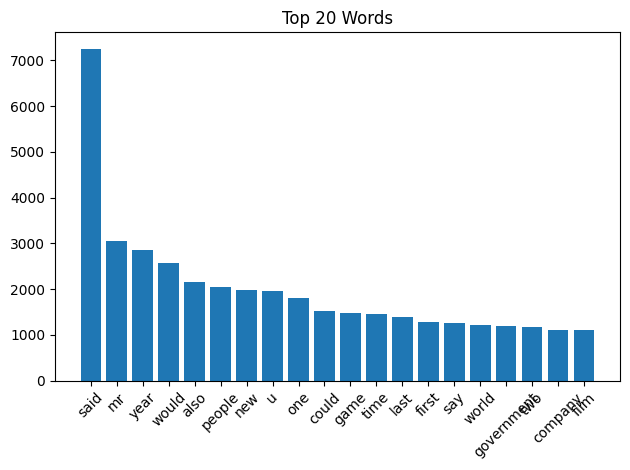

In [14]:
all_words = [word for tokens in df['tokens'] for word in tokens]

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.tight_layout()
plt.show()

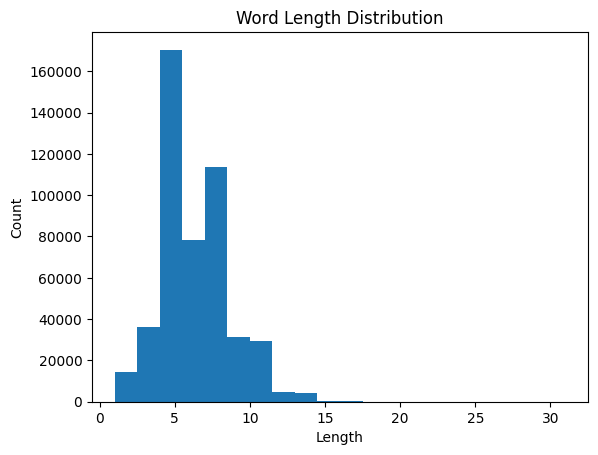

In [15]:
word_lengths = [len(word) for word in all_words]

plt.figure()
plt.hist(word_lengths, bins=20)
plt.title("Word Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

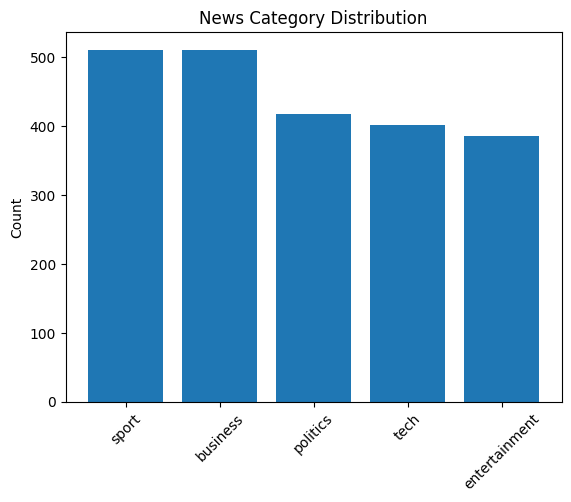

In [16]:
label_counts = df['Category'].value_counts()

plt.figure()
plt.bar(label_counts.index, label_counts.values)
plt.xticks(rotation=45)
plt.title("News Category Distribution")
plt.ylabel("Count")
plt.show()

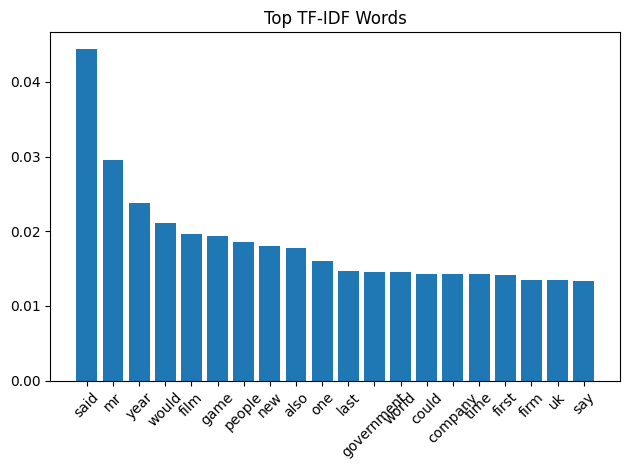

In [17]:
tfidf_means = tfidf_df.mean(axis=0)

top_tfidf = tfidf_means.sort_values(ascending=False).head(20)

plt.figure()
plt.bar(top_tfidf.index, top_tfidf.values)
plt.xticks(rotation=45)
plt.title("Top TF-IDF Words")
plt.tight_layout()
plt.show()

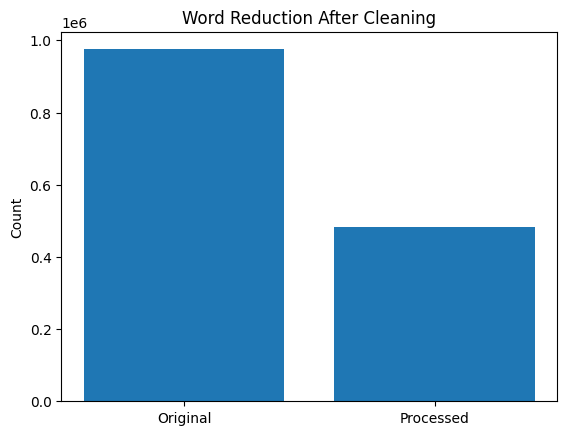

In [18]:
original_words = df['Content'].apply(lambda x: len(word_tokenize(x))).sum()
processed_words = df['tokens'].apply(len).sum()

plt.figure()
plt.bar(['Original', 'Processed'], [original_words, processed_words])
plt.title("Word Reduction After Cleaning")
plt.ylabel("Count")
plt.show()

In [19]:
df.to_csv("processed_news.csv", index=False)
tfidf_df.to_csv("tfidf_features.csv", index=False)

print("Files saved successfully ✅")

Files saved successfully ✅
